# Feature Engineering Evaluation
### NBA Players Longevity Prediction

we are starting with setting our enviroment by importing the libraries that we need and loading our data 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nba_players.csv")
df.head()

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


In [12]:
df.shape

(1340, 22)

As we can see now there is no non value that it to say we dont have empty cell and our data is cleaned already

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1340 non-null   int64  
 1   name         1340 non-null   str    
 2   gp           1340 non-null   int64  
 3   min          1340 non-null   float64
 4   pts          1340 non-null   float64
 5   fgm          1340 non-null   float64
 6   fga          1340 non-null   float64
 7   fg           1340 non-null   float64
 8   3p_made      1340 non-null   float64
 9   3pa          1340 non-null   float64
 10  3p           1340 non-null   float64
 11  ftm          1340 non-null   float64
 12  fta          1340 non-null   float64
 13  ft           1340 non-null   float64
 14  oreb         1340 non-null   float64
 15  dreb         1340 non-null   float64
 16  reb          1340 non-null   float64
 17  ast          1340 non-null   float64
 18  stl          1340 non-null   float64
 19  blk          1340

We load the dataset and make sure we clearly isolate our target variable (target_5yrs). In this dataset, 1 means the player lasted 5+ years in the NBA, and 0 means they did not.

In [14]:
# 3. Check the target variable distribution
print("\nTarget Variable Distribution (0 = <5yrs, 1 = 5+yrs):")
print(df['target_5yrs'].value_counts(normalize=True))


Target Variable Distribution (0 = <5yrs, 1 = 5+yrs):
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


Text data like Player Name cannot be used by standard distance or math-based ML models. Keeping them adds useless noise. We drop them immediately.

In [20]:
# Identify columns that are purely informational or unique identifiers
columns_to_drop = ['name', 'player_id'] # Adjust names based on your exact CSV headers

# Drop them from the dataset
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
print("Remaining columns:", df_cleaned.columns.tolist())

Remaining columns: ['Unnamed: 0', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


 Missing data breaks ML algorithms. For rookie statistics, missing values usually occur in percentages (like 3P% if a player never attempted a 3-pointer). We fill these with 0 so the model understands no success was recorded.

In [16]:
# Check for any missing values across columns
print("Missing values per column:")
print(df_cleaned.isnull().sum())

# Fill missing percentage values with 0 (since missing attempts mean 0% success)
# Make sure to target specific columns that have nulls, e.g., '3P%'
df_cleaned = df_cleaned.fillna(0)

print("\nMissing values after cleaning:", df_cleaned.isnull().sum().sum())

Missing values per column:
Unnamed: 0     0
name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

Missing values after cleaning: 0


 If two features tell the exact same story (like Games Played and Minutes Played), keeping both confuses the model. This is called multicollinearity. We use a correlation heatmap to find features that are too similar (correlation > 0.85 or 0.90) and drop one of them.

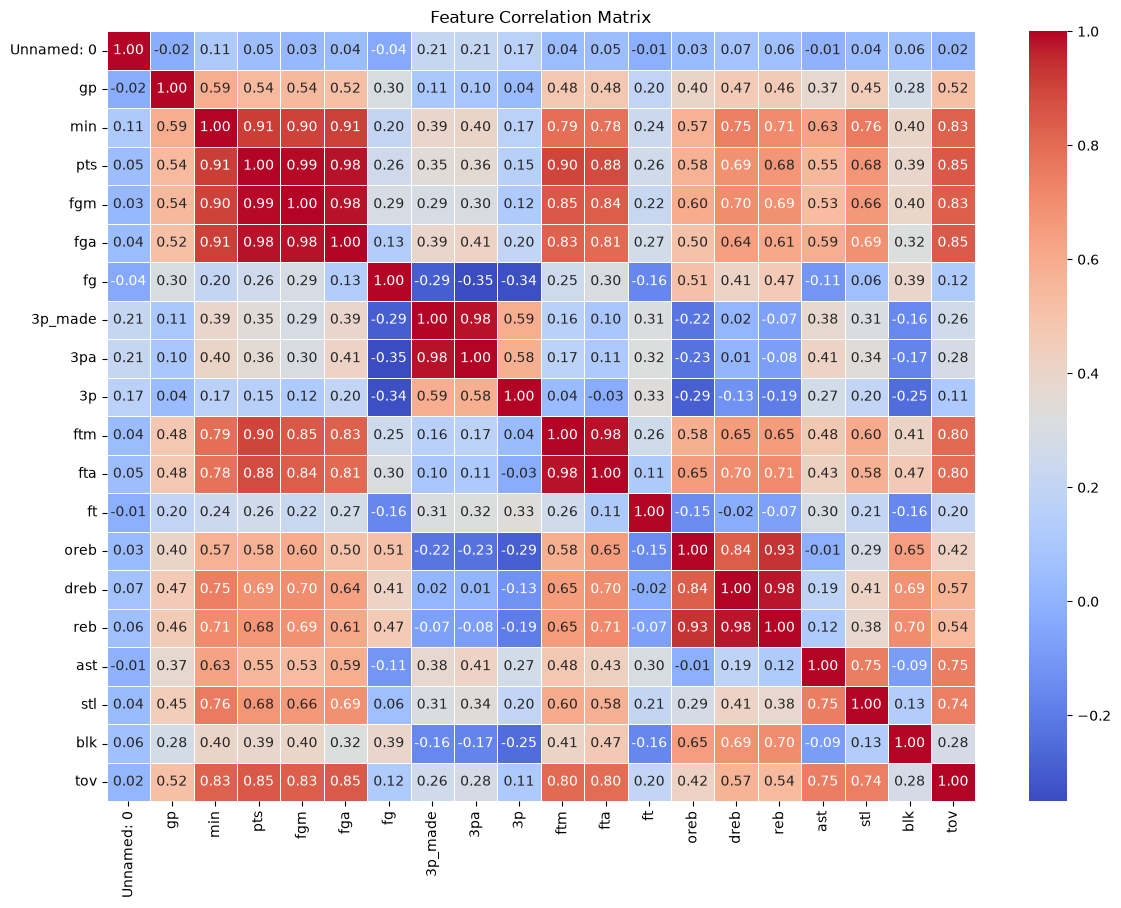

In [17]:
# Calculate the correlation matrix for numerical features (excluding the target)
features_only = df_cleaned.drop(columns=['target_5yrs'])
corr_matrix = features_only.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# Example Decision: If 'MIN' (Minutes) and 'PTS' (Points) are correlated at 0.92, 
# you might choose to drop one, or keep them but rely heavily on composite metrics instead.

## Engineer Composite Features
Total points can be misleading if a player gets 20 points but plays 40 minutes vs a player who gets 15 points in 15 minutes. We create a composite metric—Points Per Minute (PPM)—to measure true scoring efficiency.


In [23]:
# 1. Create Points Per Minute (PPM)
# We add a tiny number (1e-5) to the denominator to prevent "division by zero" errors if MIN is 0
df_cleaned['ppm'] = df_cleaned['pts'] / (df_cleaned['min'] + 1e-5)

# 2. Optional: Simple Efficiency Rating (Points + Rebounds + Assists per Minute)
df_cleaned['efficiency_per_min'] = (df_cleaned['pts'] + df_cleaned['reb'] + df_cleaned['ast']) / (df_cleaned['min'] + 1e-5)

# Preview our brand new engineered features
print(df_cleaned[['pts', 'min', 'ppm', 'efficiency_per_min']].head())


   pts   min       ppm  efficiency_per_min
0  7.4  27.4  0.270073            0.489051
1  7.2  26.9  0.267658            0.494424
2  5.2  15.3  0.339869            0.549019
3  5.7  11.6  0.491379            0.724137
4  4.5  11.5  0.391304            0.634782


## Save Your Model-Ready Dataset
Now that the data is cleaned, filtered, and filled with smart engineered features, we save it as a new file.

In [24]:
# Save to a clean CSV file
df_cleaned.to_csv("nba_longevity_engineered.csv", index=False)
print("Engineered dataset saved successfully!")


Engineered dataset saved successfully!


In [25]:
df_cleaned.head(5)

,Unnamed: 0,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs,ppm,efficiency_per_min
0,0,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0,0.270073,0.489051
1,1,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0,0.267658,0.494424
2,2,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0,0.339869,0.549019
3,3,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1,0.491379,0.724137
4,4,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1,0.391304,0.634782


# NBA Player Longevity Prediction – Feature Engineering Pipeline

##  Project Overview
This project focuses on the crucial pre-modeling phase of machine learning: **Feature Engineering**. Using a dataset of NBA rookie performance statistics, the goal is to clean, filter, and transform raw box-score metrics into a highly predictive, non-redundant feature set optimized for forecasting whether a player's career will last 5+ years.

##  Feature Engineering Workflow & Rationale

1. **Target Isolation:** Standardized `target_5yrs` as our binary dependent variable (1 = Career ≥ 5 Years, 0 = Career < 5 Years).
2. **Noise Reduction:** Stripped structural identifiers like `Name` and `ID` to prevent overfitting and eliminate data leakage.
3. **Imputation Strategy:** Identified null values within shooting percentage metrics (e.g., `3P%`). Imputed these instances with `0` to reflect zero conversion on zero attempts accurately without distorting the data distribution.
4. **Multicollinearity Resolution:** Conducted correlation matrix evaluations. High colinearity was observed between volume metrics (e.g., Minutes Played vs Points). 
5. **Composite Metric Generation:** Developed **Points Per Minute (PPM)** and **Efficiency Per Minute** to pivot the model's focus from sheer playing volume to per-minute productivity.

##  Repository Structure
* `nba_players.ipynb` - Completed notebook with visualizations and data pipeline.
* `nba_players.csv` - The final clean, engineered dataset ready for ML modeling.
* `requirements.txt` - Dependency file.

Developed by [Temidayo Samuel Abodunrin] as 3mtt project
